#前書き

「このColabノートブックは、心理尺度データの分析を通じて、PCA、因子分析、項目反応理論（IRT）の基礎を学ぶための実践的な教材です。」

作成に当たってはgemini君（＋ちょっとだけgpt君とcopilotちゃん）のサポートで作りました。このログもどこかで公開して、学生がAIを利用するためのサンプルとしたい気もしなくもない。

対称：高校情報にデータサイエンスリテラシーを魔改造でくっつけた授業用のものです。

他者の著作権への言及：このノートブックで解析するデータはThomas-Kilmann Conflict Mode Instrument (TKI) のような多次元尺度設計の考え方にインスパイアされたデータを使っています。ただし、このノートブックで使用している質問項目はTKIの公式な質問項目ではなく、著作権に配慮した独自のダミーデータです。

なお、**TKIの公式な利用には、著作権者であるThe Myers-Brings Company（日本ではJPP株式会社）の許可と購入が必要です。**

応用：一応、任意のエクセルは読み込めるので、FA,PCAの練習用に改変しても良いですけど。IRT部分はお察しで。

改変、利用はご自由に。

一応著作権は　CC:by　Koh Ikeda＠茨城高専　で。

必要なライブラリのインストール部分

#init処理部分

In [29]:
!pip install pandas numpy scipy scikit-learn matplotlib seaborn  openpyxl
!pip install factor_analyzer

ライブラリのインポート部分

In [30]:
# --- 0. 必要なライブラリのインポートと設定 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.impute import SimpleImputer
import warnings
from google.colab import files
from factor_analyzer import FactorAnalyzer # ★追加
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
# Factor Analysisの収束警告を抑制 (必要に応じて)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.decomposition._factor_analysis")

ロジスティック関数：累積正規分布関数

定義部分、IRTで使う関数。

**烏賊の軸索の話でNNの活性化関数のシグモイド関数と同等物


In [31]:
# --- 3. ロジスティック関数の定義 (2PLモデルのICC) ---
# P(theta) = c + (1 - c) / (1 + exp(-a * (theta - b)))  <- 3PLモデル
# 2PLモデルの場合 c=0 (当て推量なし)
# P(theta) = 1 / (1 + exp(-a * (theta - b)))
def logistic_icc(theta, a, b):
    # a: 識別力パラメータ (傾き)
    # b: 困難度パラメータ (平行移動)
    return 1 / (1 + np.exp(-a * (theta - b)))

#データの準備

前提１：Thomas-Kilmann Conflict Mode Instrumentのように、2軸の能力を+αから-αで表現されるとして、格象限の角を第２象限をA,第１象限をB、第3象限をD、第4象限をE、o点をCとしたカテゴリを設定する。

前提２：質問は選択式、5つのカテゴリから二つ選択し、そのカテゴリに関連した二つの文章を設定。文章の前にどのカテゴリの文章か記述されていること。

前提３：アンケート結果と、各カテゴリの数をカウントした5つの列と任意の二つのアンケートの結果を集計した（重心）列が10個

スプレッドシートxlsの読み込み

In [32]:
# --- 1. Excelファイルからのデータ読み込み ---
uploaded = files.upload()
# アップロードされたファイル名を確認（通常、ファイル名がキーとなる）
for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    excel_file_name = fn # アップロードされたファイル名を変数に格納
# ★ここを修正: アップロードされたExcelファイル名を使用
# 上記のファイルアップロードセルを実行後、excel_file_nameにファイル名が格納されます
# 実際にはアップロードセルで自動的にexcel_file_nameに代入されます。
if 'excel_file_name' not in locals():
    print("Excelファイルがアップロードされていません。上記のアップロードセルを実行してください。")
    # Colabでのファイルアップロード用のダミーコード（実行時は上のセルを先に実行）
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        excel_file_name = fn
        print(f"User uploaded file: {excel_file_name}")

Saving dummytki (3).xlsx to dummytki (3) (1).xlsx
User uploaded file "dummytki (3) (1).xlsx" with length 386342 bytes


データの前処理

＊１　エクセルファイルの該当のシートのシート名が間違っていると、エラーを吐きます。pd.read.excelでデータの入っているシート名に適宜書き換えること。

＊２　分析のためにこのコードでは解答結果が５つのラベル名A～Eを先頭に”A xxxxxx”となっていることが前提。ダミーデータやフォーム作成時に注意すること。

＊３　項目分けのラベルがどの軸の質問かをquestion_item_namesで書いてあるので、こちらも適宜直すこと。

In [33]:
question_item_names = {
   'Q1': 'AC', 'Q2': 'AC', 'Q3': 'AC', 'Q4': 'BC', 'Q5': 'BC',
    'Q6': 'BC', 'Q7': 'DC', 'Q8': 'DC', 'Q9': 'DC', 'Q10': 'EC',
   'Q11': 'EC', 'Q12': 'EC', 'Q13': 'BE', 'Q14': 'BE', 'Q15': 'BE',
   'Q16': 'AD', 'Q17': 'AD', 'Q18': 'AD', 'Q19': 'BA', 'Q20': 'BA',
   'Q21': 'BA', 'Q22': 'ED', 'Q23': 'ED', 'Q24': 'ED', 'Q25': 'AE',
   'Q26': 'AE', 'Q27': 'AE', 'Q28': 'BD', 'Q29': 'BD', 'Q30': 'BD'
}#adhockに今回のデータ用のラベル。問題の設定毎に手で設定する。質問解答から読み込んで決定する方がスマート
try:
    # header=0 で1行目をヘッダーとして読み込み、データは2行目から始まる
    # sheet_name='フォームの回答 1' のように明示的に指定する。
    df = pd.read_excel(excel_file_name, sheet_name='フォームの回答 1', header=0) # ★ header=0 を明示
    print(f"Excelファイル '{excel_file_name}' からデータを正常に読み込みました。")
    print(f"データ形状: {df.shape}")
    print("DataFrameの先頭5行:")
    print(df.head()) # ヘッダーが正しく読み込まれたか確認
except Exception as e:
    print(f"Excelファイルの読み込みエラー: {e}")
    print("ファイル名、シート名、またはファイル形式が正しいか確認してください。")
    exit()

Excelファイル 'dummytki (3) (1).xlsx' からデータを正常に読み込みました。
データ形状: (2000, 47)
DataFrameの先頭5行:
   User_ID            Timestamp Q1 Q2 Q3 Q4 Q5 Q6 Q7 Q8  ...        AC  \
0        1  2025-06-20 03:30:40  A  A  A  C  C  C  C  C  ...  1.000000   
1        2  2025-06-20 03:30:40  C  C  C  C  C  C  C  C  ...  0.000000   
2        3  2025-06-20 03:30:40  C  C  C  C  C  C  C  C  ...  0.000000   
3        4  2025-06-20 03:30:40  A  C  C  B  B  C  C  C  ...  0.333333   
4        5  2025-06-20 03:30:40  C  C  C  C  C  C  C  C  ...  0.000000   

         BC   DC        EC        BE        AD        AB        DE        AE  \
0  0.000000  0.0  0.000000  0.666667  0.000000  0.333333  0.000000  0.333333   
1  0.000000  0.0  0.000000  0.666667  1.000000  0.333333  0.000000  1.000000   
2  0.000000  0.0  0.000000  0.666667  1.000000  1.000000  0.000000  0.000000   
3  0.666667  0.0  0.333333  0.666667  1.000000  0.333333  1.000000  0.666667   
4  0.000000  0.0  0.333333  0.666667  0.666667  0.333333  0.333333  0

In [34]:


# --- 2. データ前処理 ---

# 不要な列（タイムスタンプ、ID）の削除（アンケートフォームによる）
# 最初の2列を削除
# dfの列名が読み込まれているので、列名で指定する方がより安全です
# 例: df_processed = df.drop(columns=[df.columns[0], df.columns[1]]).copy()
# もしくは、インデックスで指定
df_processed = df.iloc[:, 2:].copy()#ここの2が不必要な列の数。
# アンケート回答この例は30個のアンケートの場合（元のdfの3列目から32列目、df_processedの0列目から29列目）
question_cols_raw = df_processed.iloc[:, :30]
# 文字選択肢を数値に変換 (A=1, B=2, C=3, D=4, E=5)
# 解答が「A. これが私の意見です」のような形式に対応するため、正規表現を使用
mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
try:
    # 各セルについて、文字列の先頭の1文字（A-E）を抽出し、それをマッピング
    # .str.extract(r'^([A-Ea-e])') で文字列の先頭のA-Eを抽出
    # .iloc[:, 0] で抽出されたDataFrameの最初の列（抽出された文字）を選択
    # .str.upper() で大文字に統一
    # .map(mapping) で数値に変換
    question_data = question_cols_raw.apply(
        lambda col: col.astype(str).str.extract(r'^([A-Ea-e])', expand=False).str.upper().map(mapping)
    )
    # 数値に変換できないもの（NaNなど）はそのまま残る可能性があるため、型変換を試みる
    question_data = question_data.apply(pd.to_numeric, errors='coerce')
    print("アンケート回答の文字を数値に変換しました。")
    print("変換後のアンケート回答データの先頭5行:")
    print(question_data.head())
except Exception as e:
    print(f"アンケート回答の数値変換エラー: {e}")
    print("アンケート回答の列に予期せぬ値が含まれているか、変換ルールを確認してください。")
    exit()

# 欠損値の処理: 平均値で補完
imputer = SimpleImputer(strategy='mean')
question_data_imputed = pd.DataFrame(imputer.fit_transform(question_data), columns=question_data.columns)
print(f"アンケート回答データの欠損値を平均値で補完しました。補完後の形状: {question_data_imputed.shape}")

# カテゴリ集計データ (df_processedの30列目から34列目, Pythonインデックスでは29列目から33列目)
# df_processedのインデックスは0から始まるため、30番目から34番目の列（アンケート数により、指定は変わる）
catg_aggregated_data = df_processed.iloc[:, 30:35]
catg_aggregated_data = catg_aggregated_data.apply(pd.to_numeric, errors='coerce')
catg_aggregated_data_imputed = pd.DataFrame(imputer.fit_transform(catg_aggregated_data), columns=catg_aggregated_data.columns)
print(f"カテゴリ集計データの欠損値を平均値で補完しました。補完後の形状: {catg_aggregated_data_imputed.shape}")

# 重心計算データ (df_processedの35列目から44列目, Pythonインデックスでは34列目から43列目)
# df_processedのインデックスは0から始まるため、35番目から44番目の列
centroid_data = df_processed.iloc[:, 35:45]
centroid_data = centroid_data.apply(pd.to_numeric, errors='coerce')
centroid_data_imputed = pd.DataFrame(imputer.fit_transform(centroid_data), columns=centroid_data.columns)
print(f"重心計算データの欠損値を平均値で補完しました。補完後の形状: {centroid_data_imputed.shape}")
# --- ★追加: catg集計データと重心計算データの列名ラベル付け ---
# catg集計データの列名変更
catg_aggregated_data_imputed.columns = ['A', 'B', 'C', 'D', 'E'] # ★追加
print("\ncatg集計データの列名を ['A', 'B', 'C', 'D', 'E'] に変更しました。")

# 重心計算データの列名変更
centroid_labels = ['BA', 'BC', 'BD', 'BE', 'ED', 'EC', 'EA', 'AC', 'DC', 'AD'] # ★追加
if len(centroid_labels) == centroid_data_imputed.shape[1]: # 列数とラベル数が一致するか確認
    centroid_data_imputed.columns = centroid_labels # ★追加
    print(f"重心計算データの列名を {centroid_labels} に変更しました。")
else:
    print("警告: 重心計算データの列数と指定されたラベル数が一致しません。列名変更をスキップしました。") # ★追加

# 全てのデータでスケールを統一 (PCAやFAの前に重要)
scaler = StandardScaler()
question_data_scaled = scaler.fit_transform(question_data_imputed)
#catg_aggregated_data_scaled = scaler.fit_transform(catg_aggregated_data_imputed)
#centroid_data_scaled = scaler.fit_transform(centroid_data_imputed)
catg_aggregated_data_scaled = scaler.fit_transform(catg_aggregated_data_imputed) # 列名が変更されたDataFrameを渡す
centroid_data_scaled = scaler.fit_transform(centroid_data_imputed) # 列名が変更されたDataFrameを渡す

# データフレームに戻す（列名を保持するため）
question_data_scaled_df = pd.DataFrame(question_data_scaled, columns=question_data_imputed.columns)
catg_aggregated_data_scaled_df = pd.DataFrame(catg_aggregated_data_scaled, columns=catg_aggregated_data_imputed.columns)
centroid_data_scaled_df = pd.DataFrame(centroid_data_scaled, columns=centroid_data_imputed.columns)

print("\n--- データ前処理完了 ---")


アンケート回答の文字を数値に変換しました。
変換後のアンケート回答データの先頭5行:
   Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10  ...  Q21  Q22  Q23  Q24  Q25  Q26  \
0   1   1   1   3   3   3   3   3   3    3  ...    1    4    4    4    1    5   
1   3   3   3   3   3   3   3   3   3    3  ...    1    4    4    4    1    1   
2   3   3   3   3   3   3   3   3   3    3  ...    2    4    4    4    5    5   
3   1   3   3   2   2   3   3   3   3    5  ...    1    5    5    5    5    1   
4   3   3   3   3   3   3   3   3   3    3  ...    1    4    4    5    1    1   

   Q27  Q28  Q29  Q30  
0    5    2    2    4  
1    1    4    4    4  
2    5    4    2    4  
3    1    2    2    2  
4    5    4    4    2  

[5 rows x 30 columns]
アンケート回答データの欠損値を平均値で補完しました。補完後の形状: (2000, 30)
カテゴリ集計データの欠損値を平均値で補完しました。補完後の形状: (2000, 5)
重心計算データの欠損値を平均値で補完しました。補完後の形状: (2000, 10)

catg集計データの列名を ['A', 'B', 'C', 'D', 'E'] に変更しました。
重心計算データの列名を ['BA', 'BC', 'BD', 'BE', 'ED', 'EC', 'EA', 'AC', 'DC', 'AD'] に変更しました。

--- データ前処理完了 ---


#**PCA：principal component analysis（主成分分析）**



複数のカテゴリを実際の意味のあるカテゴリに少なくして
説明するための統計分析手法。ここの例は５カテゴリを
2軸（もしくは3軸）の能力で説明するために使用。

関数定義部分

In [35]:
# --- 3. PCAの実行と可視化 ---

def run_pca_and_plot(data_df, title_prefix):
    """PCAを実行し、固有値プロットとbiplotを生成する関数"""
    print(f"\n--- {title_prefix} PCA分析 ---")
    pca = PCA()
    pca.fit(data_df)

    # 固有値（分散説明率）のプロット
    plt.figure(figsize=(10, 6))
    plt.plot((pca.explained_variance_ratio_))#各バリアンスの値を直接プロットしたい場合。ここと下のどちらかを使うと良い。
#    plt.plot(np.cumsum(pca.explained_variance_ratio_))#累積値で見たい時用。
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(f'{title_prefix} Cumulative Explained Variance by Principal Components')
    plt.grid(True)
    plt.show()

    # 個別の寄与率も確認
    print(f"{title_prefix} Explained Variance Ratio per Component:")
    for i, ratio in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {ratio:.4f} (Cumulative: {np.cumsum(pca.explained_variance_ratio_)[i]:.4f})")

    # 最初の3主成分でのbiplot
    pca_result = PCA(n_components=3) #
    components = pca_result.fit_transform(data_df)
    loadings = pca_result.components_.T * np.sqrt(pca_result.explained_variance_) #  3成分の負荷量を取得
    fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # ★修正: 1行3列のサブプロットを作成
    plot_combinations = [(0, 1, '1st vs 2nd'), (0, 2, '1st vs 3rd'), (1, 2, '2nd vs 3rd')] # ★追加
    for idx, (pc_x, pc_y, title_suffix) in enumerate(plot_combinations): # ★追加
        ax = axes[idx] # ★追加: 現在のサブプロット軸を選択
        sns.scatterplot(x=components[:, pc_x], y=components[:, pc_y], alpha=0.6, ax=ax) # ★修正: axを指定
        for i, feature in enumerate(data_df.columns):
            arrow_length = np.sqrt(loadings[i, pc_x]**2 + loadings[i, pc_y]**2) # ★修正: 該当する軸の負荷量を使用
            if arrow_length > 0:
                scale_factor = min(np.max(np.abs(components[:, [pc_x, pc_y]])) / np.max(np.abs(loadings[:, [pc_x, pc_y]])), 1.0) * 0.8
                ax.arrow(0, 0, loadings[i, pc_x] * scale_factor, loadings[i, pc_y] * scale_factor, # ★修正: ax.arrowを使用
                          color='r', alpha=0.7, head_width=0.05 * np.max(np.abs(components[:, [pc_x, pc_y]])))
                ax.text(loadings[i, pc_x] * scale_factor * 1.15, loadings[i, pc_y] * scale_factor * 1.15, # ★修正: ax.textを使用
                         feature, color='g', ha='center', va='center', fontsize=9)

        ax.set_xlabel(f'Principal Component {pc_x+1} ({pca_result.explained_variance_ratio_[pc_x]*100:.2f}%)') # ★修正
        ax.set_ylabel(f'Principal Component {pc_y+1} ({pca_result.explained_variance_ratio_[pc_y]*100:.2f}%)') # ★修正
        ax.set_title(f'{title_prefix} PCA Biplot ({title_suffix} Components)') # ★修正
        ax.axhline(0, color='grey', lw=0.5) # ★修正: ax.axhlineを使用
        ax.axvline(0, color='grey', lw=0.5) # ★修正: ax.axvlineを使用
        ax.grid(True)
    plt.subplots_adjust(hspace=0.5)
    plt.tight_layout() # ★追加: サブプロット間のスペースを調整
    plt.show()

    return pca_result, components, loadings

PCAアナリシス実行部分、カテゴリー、重心、アンケートの3つ。実行部を3つに分けてそれぞれ実行できるようにしても良い。


--- catg Aggregated Data PCA分析 ---


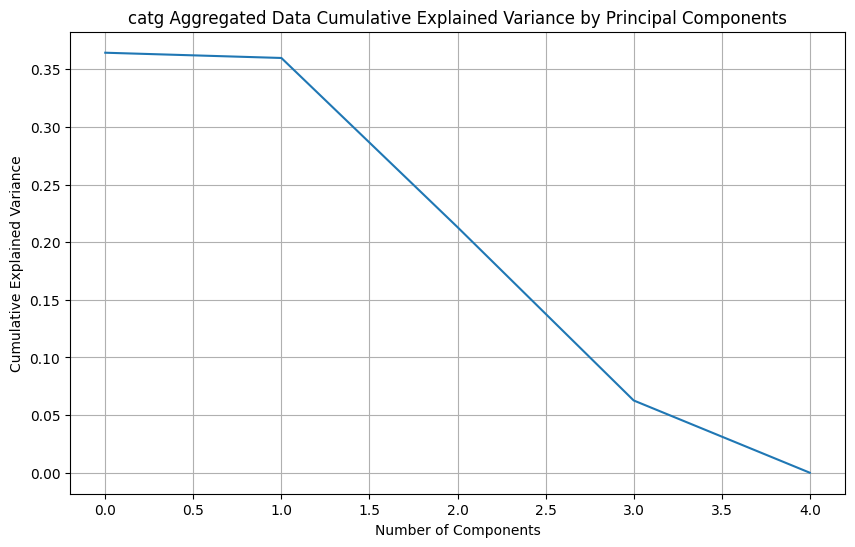

catg Aggregated Data Explained Variance Ratio per Component:
  PC1: 0.3644 (Cumulative: 0.3644)
  PC2: 0.3598 (Cumulative: 0.7242)
  PC3: 0.2131 (Cumulative: 0.9373)
  PC4: 0.0627 (Cumulative: 1.0000)
  PC5: 0.0000 (Cumulative: 1.0000)


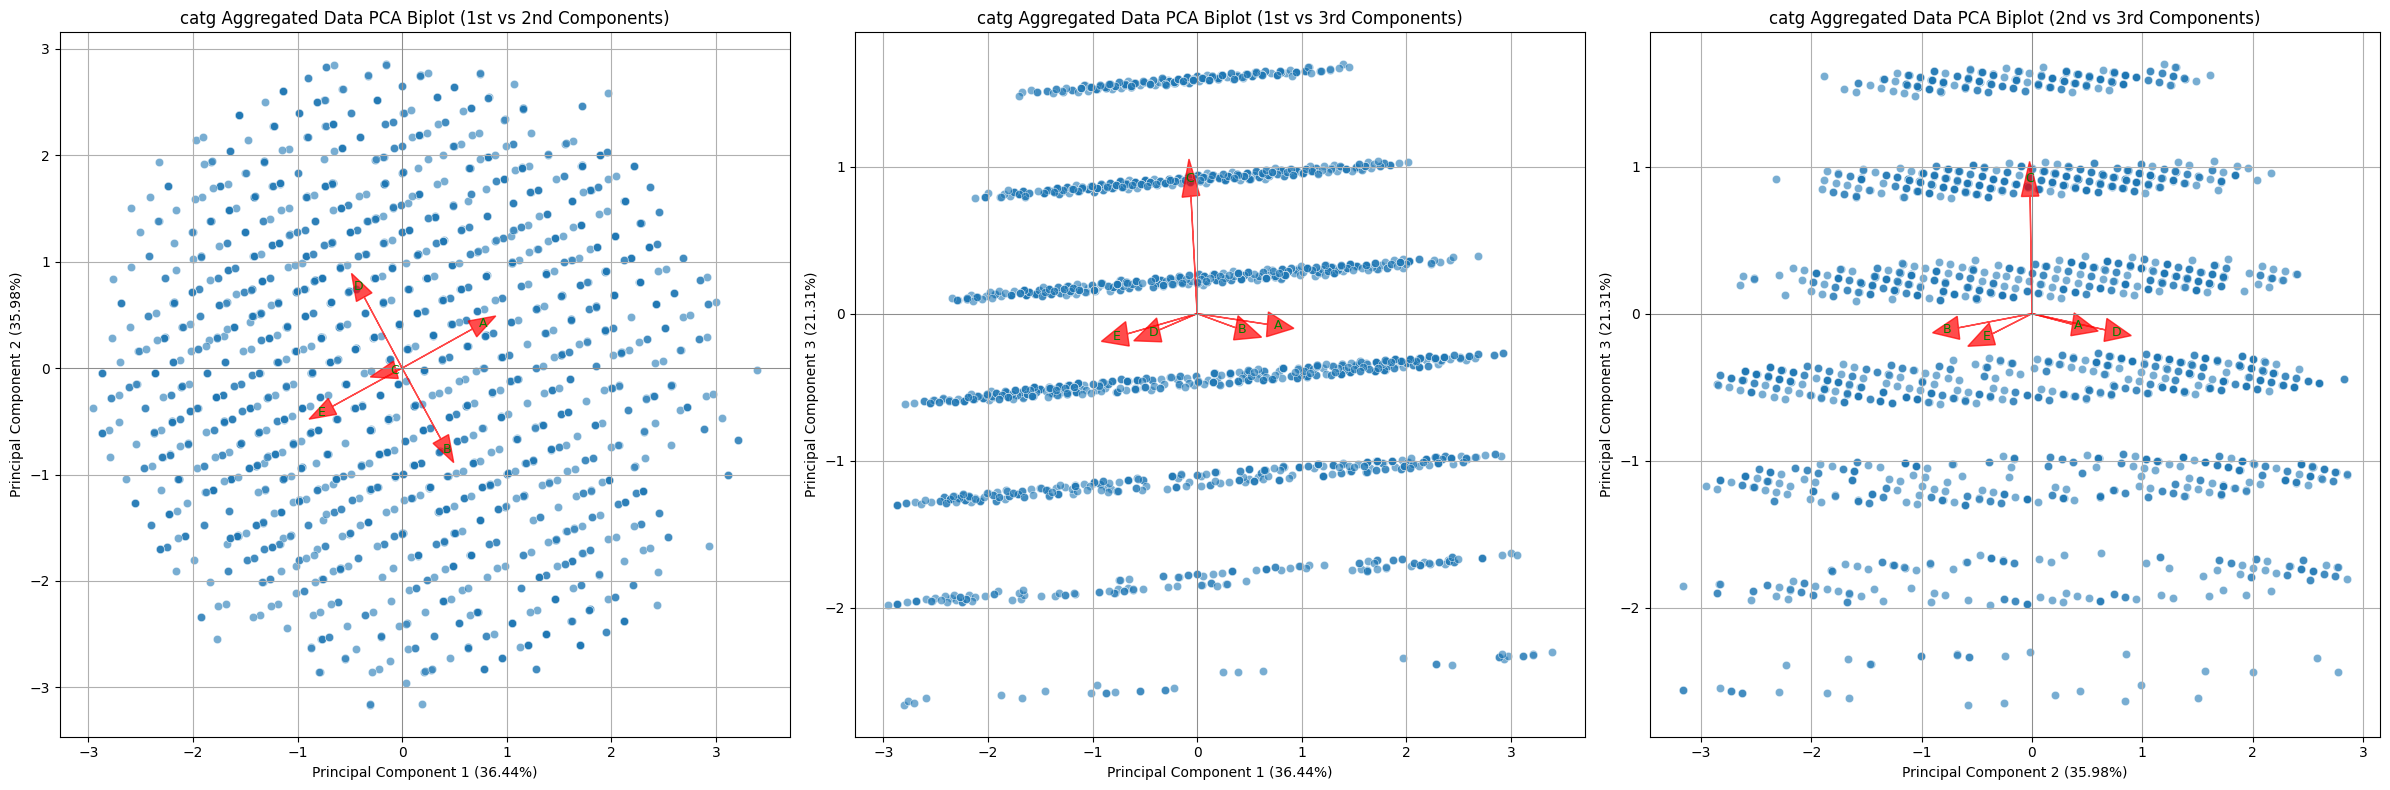


--- Centroid Data PCA分析 ---


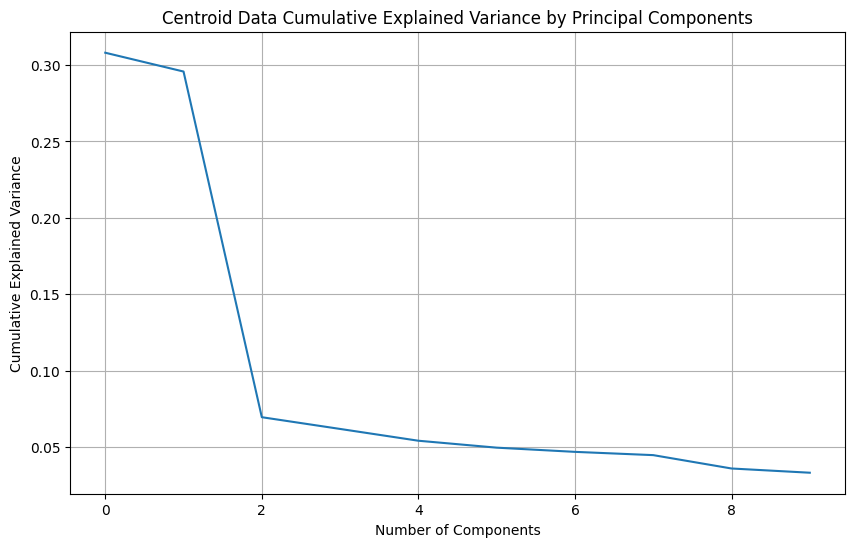

Centroid Data Explained Variance Ratio per Component:
  PC1: 0.3081 (Cumulative: 0.3081)
  PC2: 0.2958 (Cumulative: 0.6039)
  PC3: 0.0696 (Cumulative: 0.6734)
  PC4: 0.0619 (Cumulative: 0.7353)
  PC5: 0.0542 (Cumulative: 0.7895)
  PC6: 0.0496 (Cumulative: 0.8391)
  PC7: 0.0469 (Cumulative: 0.8860)
  PC8: 0.0447 (Cumulative: 0.9308)
  PC9: 0.0360 (Cumulative: 0.9668)
  PC10: 0.0332 (Cumulative: 1.0000)


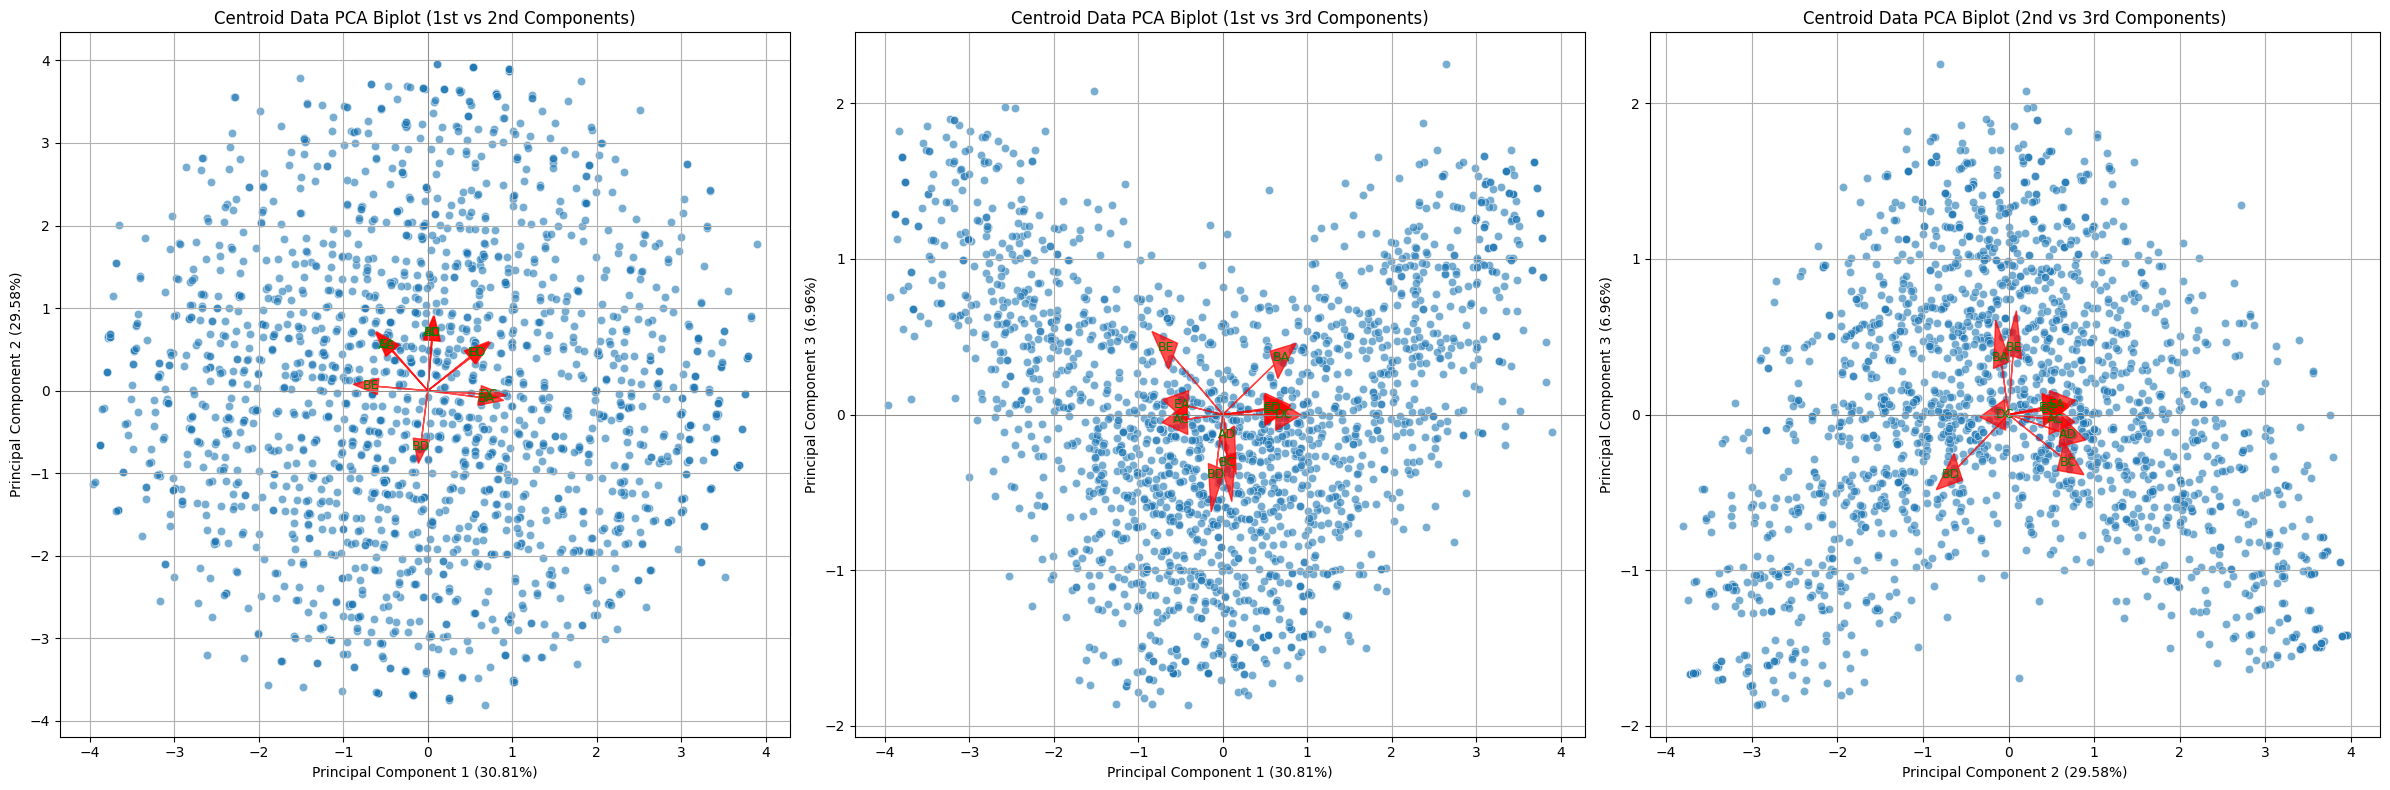

In [36]:
# catg集計データに対するPCA
pca_catg, components_catg, loadings_catg = run_pca_and_plot(catg_aggregated_data_scaled_df, "catg Aggregated Data")

# 重心計算データに対するPCA
pca_centroid, components_centroid, loadings_centroid = run_pca_and_plot(centroid_data_scaled_df, "Centroid Data")

# アンケート回答データに対するPCA (3軸の可能性検証のため)
#pca_questions, components_questions, loadings_questions = run_pca_and_plot(question_data_scaled_df, "Raw Question Data")


#**因子分析（factor analysis:FA)**



関数定義部分

In [37]:
# --- 4. FAの実行と可視化 ---

def run_fa_and_plot(data_df, title_prefix, n_factors, rotation=None):
    """因子分析を実行し、因子負荷量とbiplotを生成する関数"""
    rotation_name = rotation if rotation else "None"
    fa = FactorAnalyzer(n_factors=n_factors, rotation=rotation)
    # rotation_kwargsはPromaxなどの収束を助けるために追加することがあります。
    fa.fit(data_df)
    #loadings = fa.components_.T
    loadings = fa.loadings_
    loadings_df = pd.DataFrame(loadings, index=data_df.columns, columns=[f'Factor {i+1}' for i in range(n_factors)])
    print(f"{title_prefix} Factor Loadings (Rotation: {rotation_name}):\n", loadings_df)
    components=fa.transform(data_df)
    # biplot for Factor Analysis (因子負荷量のみ)
    # 2次元のbiplotを想定
    if n_factors >= 2:
        plt.figure(figsize=(12, 10))
        for i, feature in enumerate(data_df.columns):
            # 矢印の長さを調整して見やすくする
            arrow_length = np.sqrt(loadings[i, 0]**2 + loadings[i, 1]**2)
            if arrow_length > 0:
                # プロット範囲に合わせて矢印の長さを調整（PCAと同じロジック）
                # FAではコンポーネントがないので、負荷量の最大値でスケールを決定
                max_loading_abs = np.max(np.abs(loadings[:, :2])) if np.max(np.abs(loadings[:, :2])) > 0 else 1.0 # ゼロ除算回避
                scale_factor = 0.8 / max_loading_abs
                plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor,
                          color='r', alpha=0.7, head_width=0.05 * scale_factor)
                plt.text(loadings[i, 0] * scale_factor * 1.15, loadings[i, 1] * scale_factor * 1.15,
                         feature, color='g', ha='center', va='center', fontsize=9)
        plt.xlabel(f'Factor 1')
        plt.ylabel(f'Factor 2')
        plt.title(f'{title_prefix} Factor Analysis Biplot (Rotation: {rotation_name})')
        plt.axhline(0, color='grey', lw=0.5)
        plt.axvline(0, color='grey', lw=0.5)
        plt.grid(True)
        plt.show()
    else:
        print("2次元以上の因子がないため、Biplotは生成されません。")
    if n_factors == 3:
        fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # ★修正: 1行3列のサブプロットを作成
        plot_combinations = [(0, 1, '1st vs 2nd'), (0, 2, '1st vs 3rd'), (1, 2, '2nd vs 3rd')] # ★追加
        for idx, (pc_x, pc_y, title_suffix) in enumerate(plot_combinations): # ★追加
            ax = axes[idx] # ★追加: 現在のサブプロット軸を選択
        sns.scatterplot(x=components[:, pc_x], y=components[:, pc_y], alpha=0.6, ax=ax) # ★修正: axを指定
        for i, feature in enumerate(data_df.columns):
            arrow_length = np.sqrt(loadings[i, pc_x]**2 + loadings[i, pc_y]**2) # ★修正: 該当する軸の負荷量を使用
            if arrow_length > 0:
                scale_factor = min(np.max(np.abs(components[:, [pc_x, pc_y]])) / np.max(np.abs(loadings[:, [pc_x, pc_y]])), 1.0) * 0.8
                ax.arrow(0, 0, loadings[i, pc_x] * scale_factor, loadings[i, pc_y] * scale_factor, # ★修正: ax.arrowを使用
                          color='r', alpha=0.7, head_width=0.05 * np.max(np.abs(components[:, [pc_x, pc_y]])))
                ax.text(loadings[i, pc_x] * scale_factor * 1.15, loadings[i, pc_y] * scale_factor * 1.15, # ★修正: ax.textを使用
                         feature, color='g', ha='center', va='center', fontsize=9)

        ax.set_xlabel(f'FACTOR {pc_x+1}' ) # ★修正
        ax.set_ylabel(f'FACTOR {pc_y+1}') # ★修正
        ax.set_title(f'{title_prefix} FA Biplot ({title_suffix} Components)') # ★修正
        ax.axhline(0, color='grey', lw=0.5) # ★修正: ax.axhlineを使用
        ax.axvline(0, color='grey', lw=0.5) # ★修正: ax.axvlineを使用
        ax.grid(True)
    plt.subplots_adjust(hspace=0.5)
    plt.tight_layout() # ★追加: サブプロット間のスペースを調整
    plt.show()
    return fa

FA実行部分

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


catg Aggregated Data Factor Loadings (Rotation: varimax):
    Factor 1  Factor 2  Factor 3
A  0.928652 -0.002941 -0.129478
B -0.003893  0.925738 -0.116240
C -0.016970 -0.003401  1.001232
D -0.006155 -0.878361 -0.105834
E -0.887066 -0.010572 -0.098301


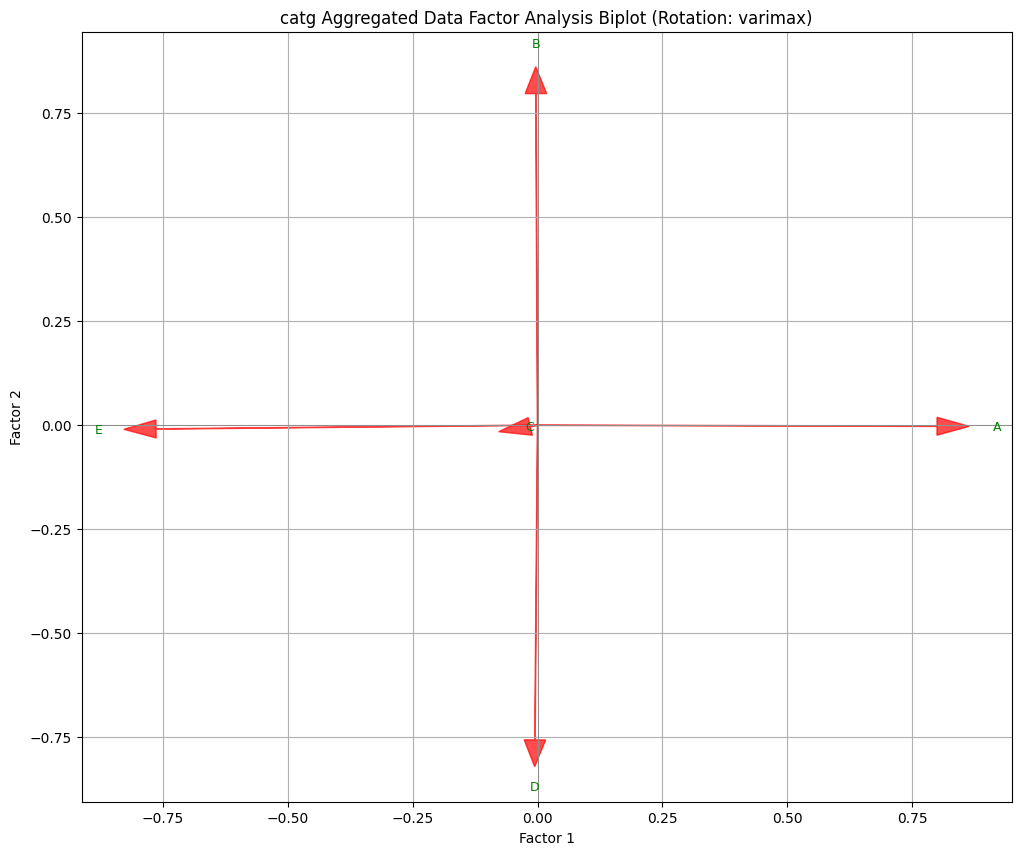

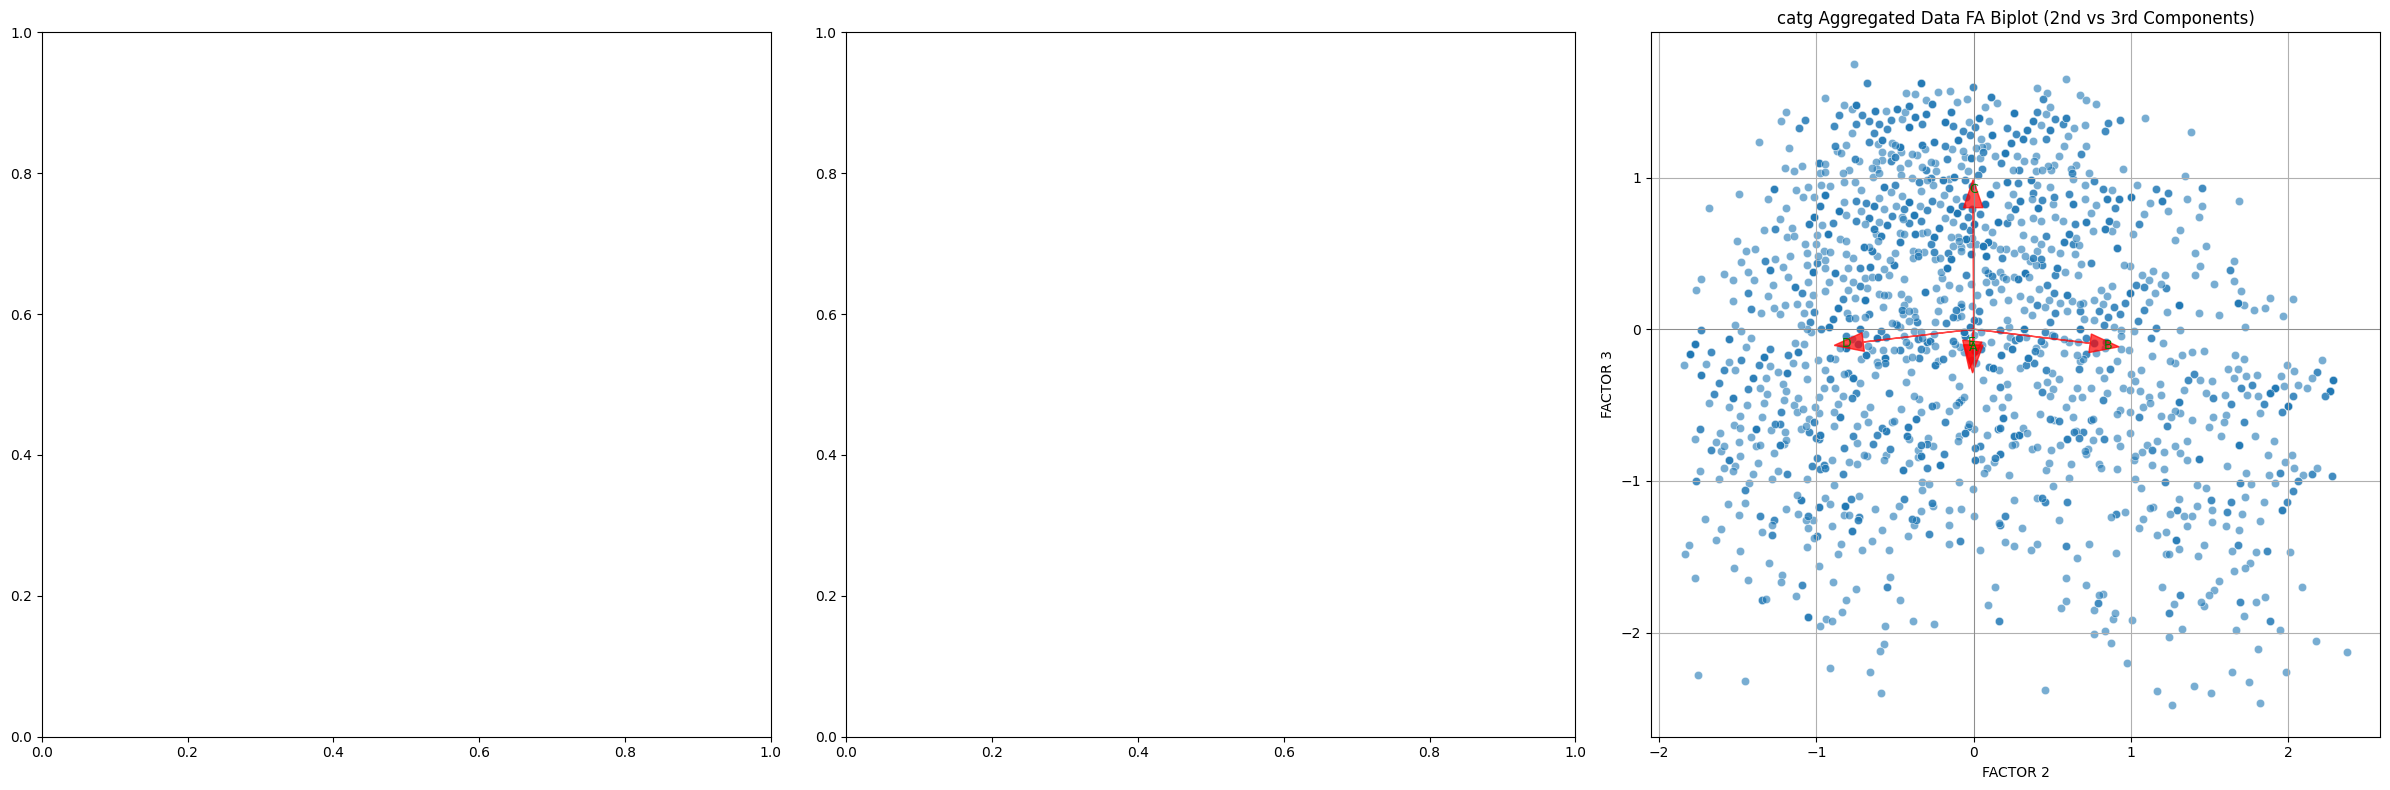

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


catg Aggregated Data Factor Loadings (Rotation: promax):
    Factor 1  Factor 2  Factor 3
A  0.926869 -0.007224 -0.117874
B -0.006986  0.925579 -0.115043
C -0.001046 -0.001734  1.001345
D -0.006660 -0.878512 -0.107164
E -0.888876 -0.006834 -0.109477


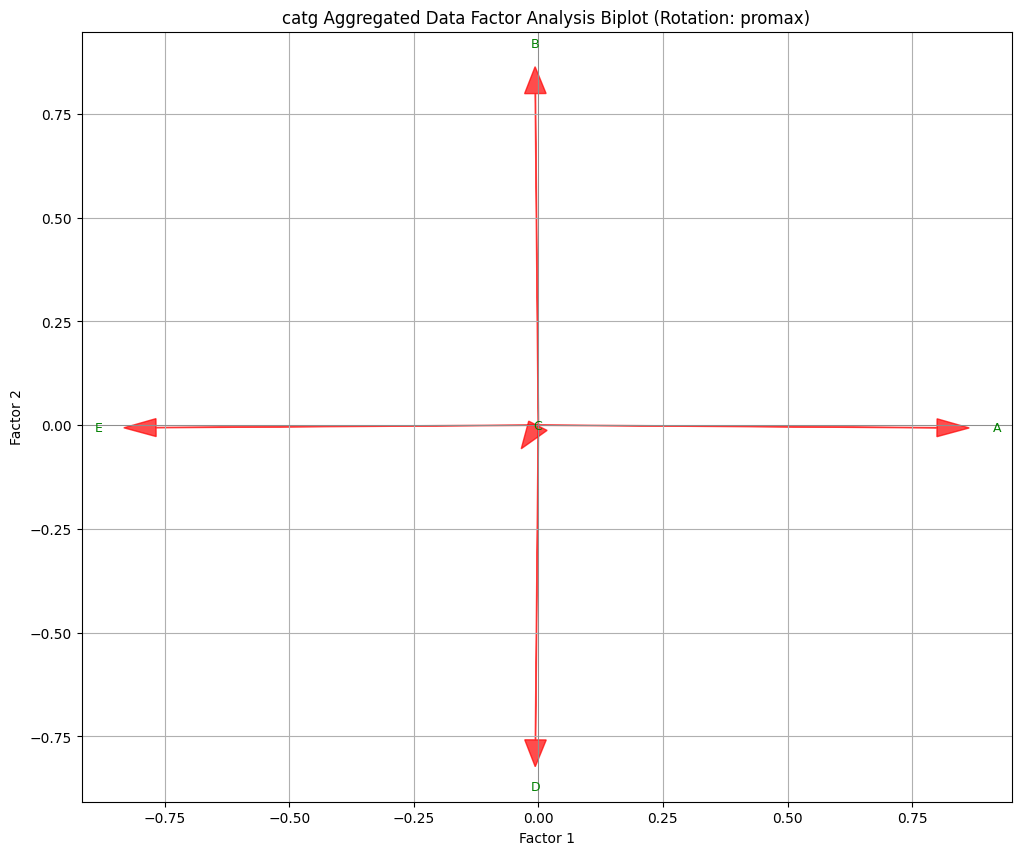

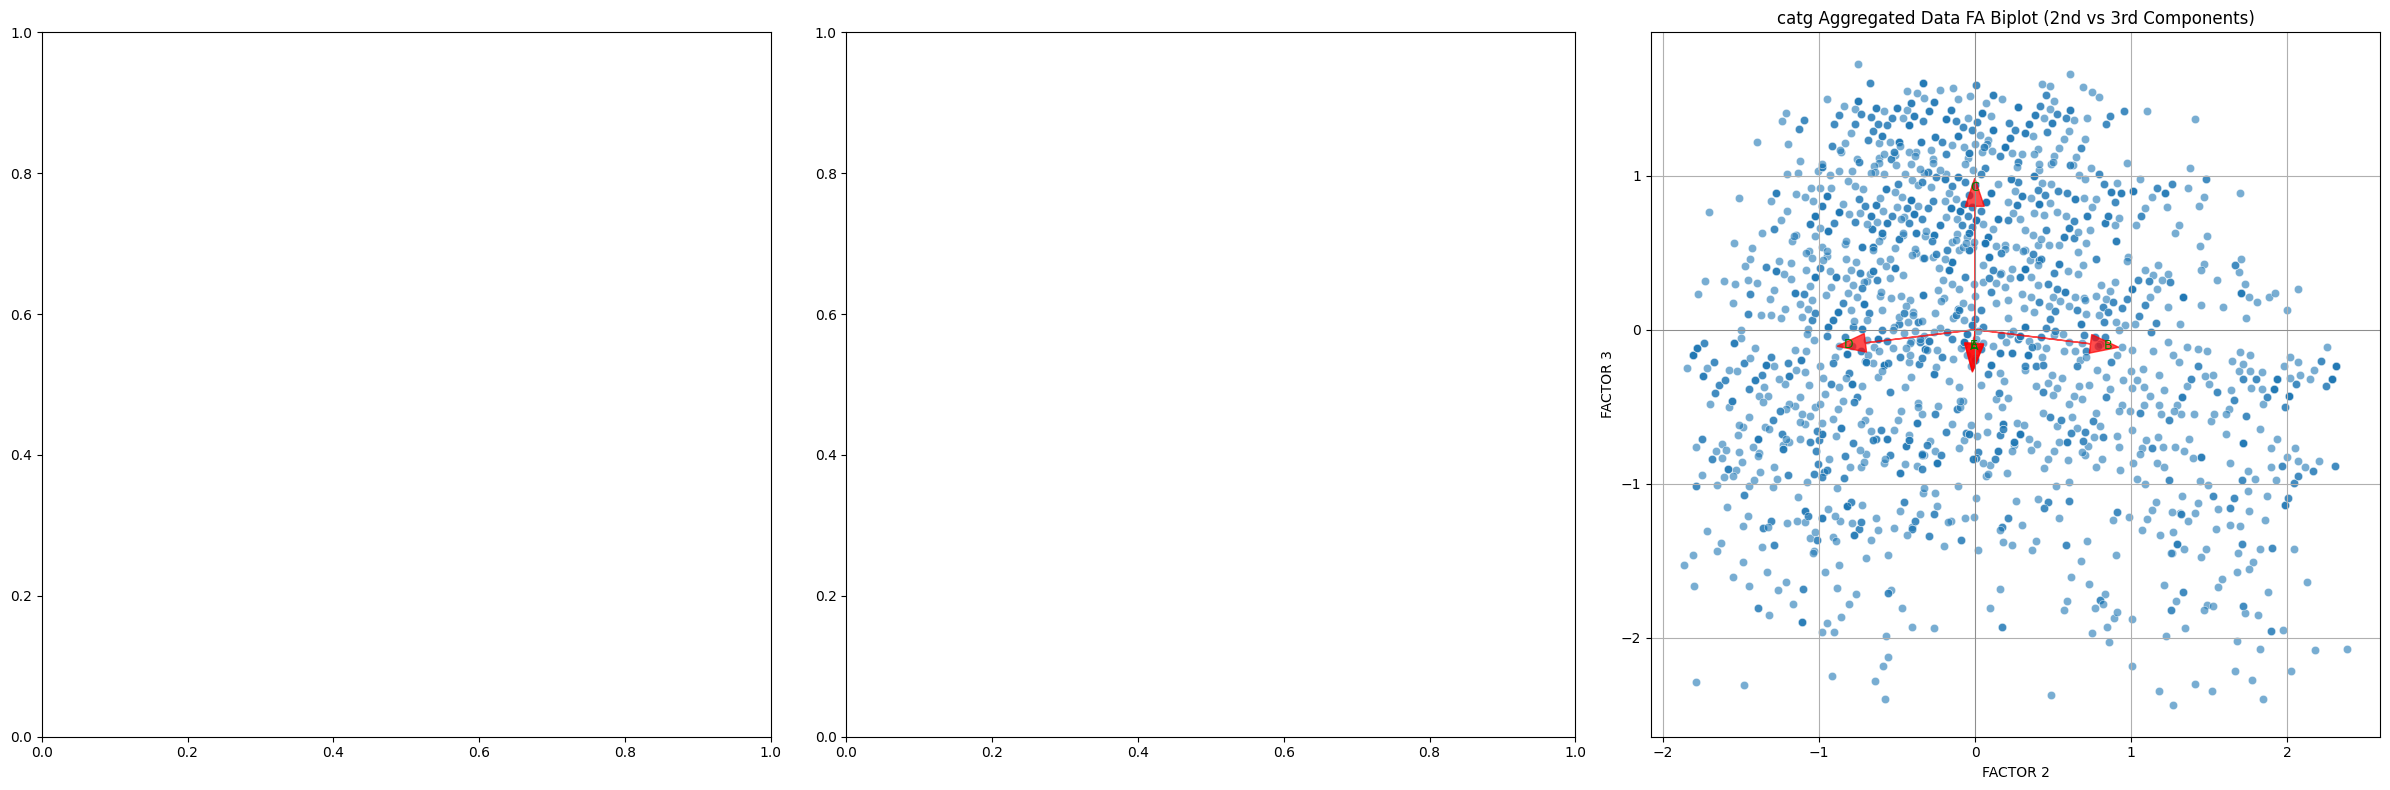

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Centroid Data Factor Loadings (Rotation: varimax):
     Factor 1  Factor 2  Factor 3  Factor 4
BA  0.805839  0.042161 -0.017253 -0.070874
BC -0.037442  0.339630  0.937289 -0.006531
BD  0.015776 -0.762186 -0.105039 -0.027146
BE -0.340660 -0.022639 -0.009547  0.937275
ED  0.446137  0.492910  0.230958 -0.236553
EC  0.425401  0.486740  0.239080 -0.228495
EA -0.494010  0.423942  0.225366  0.244420
AC -0.510317  0.396800  0.236932  0.220909
DC  0.629307  0.065018  0.015206 -0.310948
AD -0.066591  0.556431  0.357586 -0.016888


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


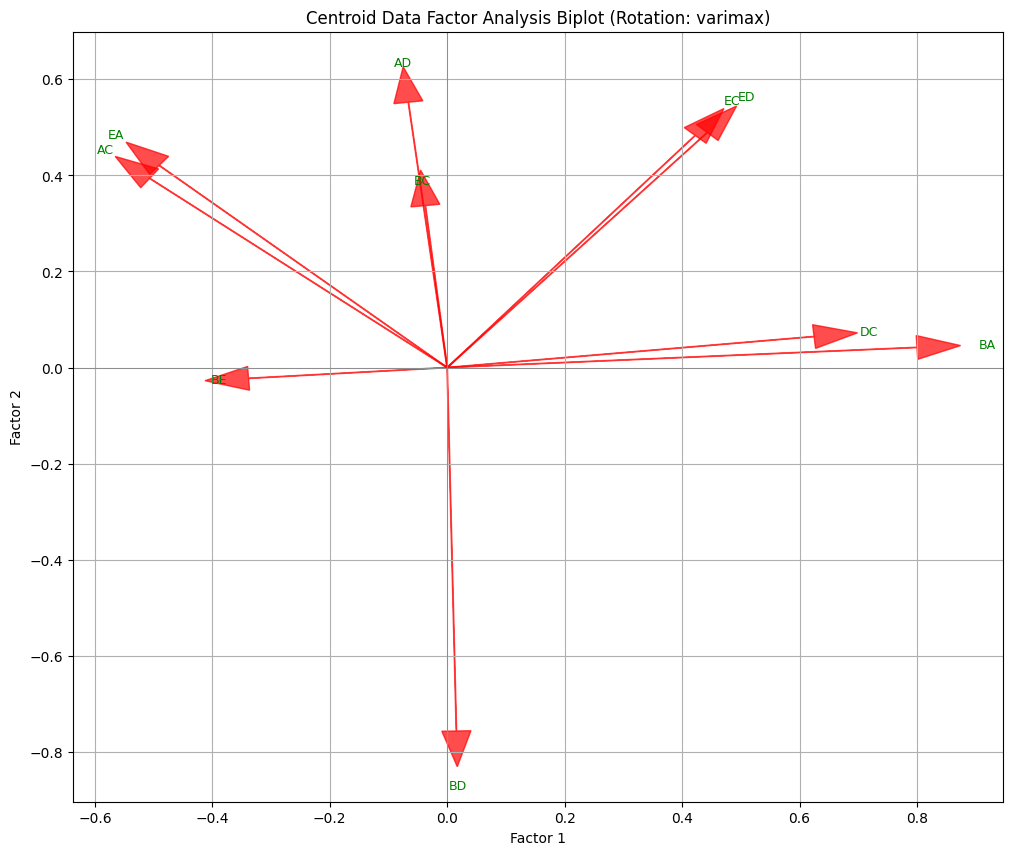

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Centroid Data Factor Loadings (Rotation: promax):
     Factor 1  Factor 2  Factor 3  Factor 4
BA  0.995532  0.047894  0.007823  0.285325
BC  0.012276 -0.223059  1.156926  0.033488
BD  0.008234 -0.947153  0.259172 -0.036258
BE  0.219182 -0.001931  0.029114  1.148421
ED  0.421004  0.479375  0.084506 -0.103231
EC  0.400486  0.465840  0.098413 -0.101338
EA -0.460559  0.421126  0.072859  0.119795
AC -0.496953  0.376411  0.101433  0.079866
DC  0.598381  0.056124  0.014728 -0.133166
AD -0.081905  0.488678  0.206987 -0.032990


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


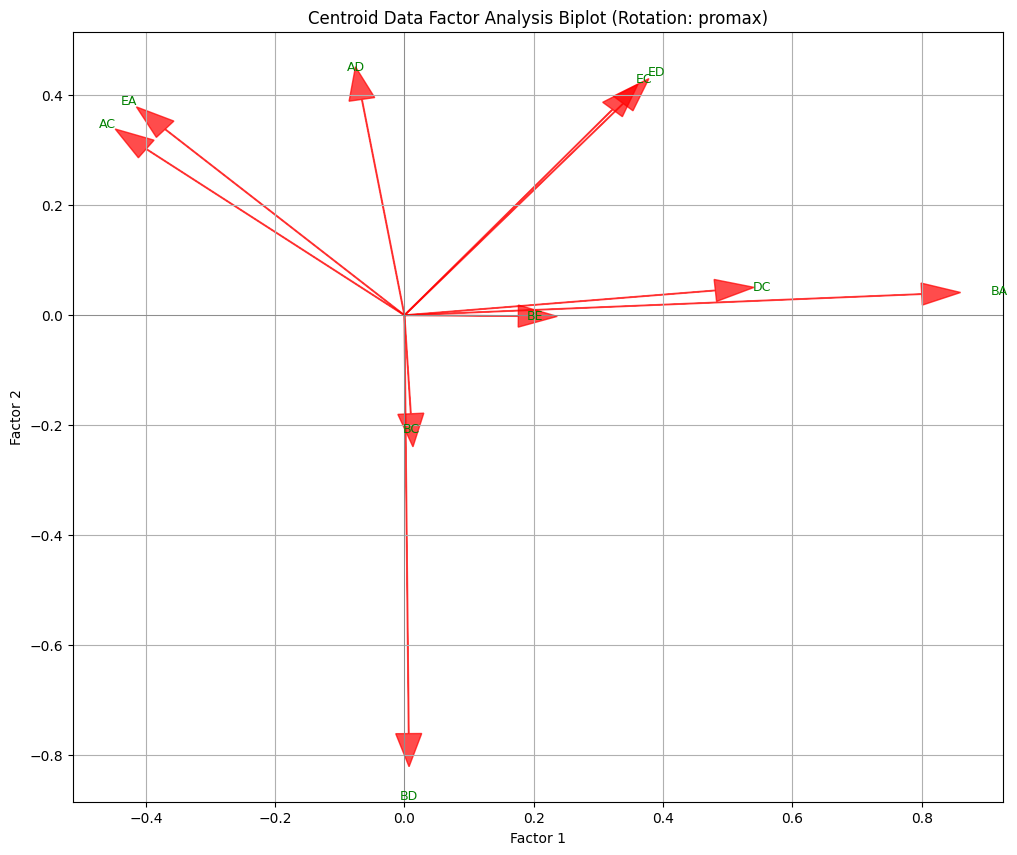

<Figure size 640x480 with 0 Axes>

In [38]:
# catg集計データに対するFA (2因子, Varimax, Promax)
fa_catg_varimax = run_fa_and_plot(catg_aggregated_data_scaled_df, "catg Aggregated Data", n_factors=3, rotation='varimax')
fa_catg_promax = run_fa_and_plot(catg_aggregated_data_scaled_df, "catg Aggregated Data", n_factors=3, rotation='promax')

# 重心計算データに対するFA (2因子, Varimax, Promax)
fa_centroid_varimax = run_fa_and_plot(centroid_data_scaled_df, "Centroid Data", n_factors=4, rotation='varimax')
fa_centroid_promax = run_fa_and_plot(centroid_data_scaled_df, "Centroid Data", n_factors=4, rotation='promax')

# アンケート回答データに対するFA (2因子と3因子で試行, Varimax, Promax)
# 2因子
#fa_q_2_varimax = run_fa_and_plot(question_data_scaled_df, "Raw Question Data", n_factors=2, rotation='varimax')
#fa_q_2_promax = run_fa_and_plot(question_data_scaled_df, "Raw Question Data", n_factors=2, rotation='promax')

# 3因子 (項目C関連の3軸目存在可能性の検証)
#fa_q_3_varimax = run_fa_and_plot(question_data_scaled_df, "Raw Question Data", n_factors=3, rotation='varimax')
#fa_q_3_promax = run_fa_and_plot(question_data_scaled_df, "Raw Question Data", n_factors=3, rotation='promax')

# IRT

通常のIRTはすべての質問を使って、統計的、確率的な過程を仮定して、θ、a,bを分析する。

(py-irt,pyirtやmirtなどのパッケージを使う）

ここでは、IRTのコンセプトに従い、特定の能力に対して、能力毎に計算した平均正答率を使う。
ここから、ロジスティック関数を**非線形最小二乗法**でフィッティングしてa,bを推定。


基本的には数学的にはAI回で最初に話した回帰直線計算の凄い版

**2能力値以上の場合は実際はロジスティック関数のような線で分類できないので多次元IRT（multi dimensional IRT)を利用して多次元曲面を推定する。

In [39]:
# データフレームの列名をQ1, Q2...のようにリネームすると、IRT結果が分かりやすくなります
original_question_columns = question_data_imputed.columns
question_data_imputed.columns = [f'Q{i+1}' for i in range(question_data_imputed.shape[1])]

# 簡易的な二値化: 各質問の回答がその質問の平均値より大きいか否か
binarized_question_data = (question_data_imputed > question_data_imputed.mean()).astype(int)
scaler = StandardScaler()
question_data_scaled = scaler.fit_transform(binarized_question_data)

#pcaの結果に基づく因子量計算 catg,centroid
theta_pca_catg_scores = pca_catg.fit_transform(question_data_scaled)#PCAの結果利用
#theta_pca_catg_scores = pca_centroid.fit_transform(question_data_scaled)#FAの結果を利用する場合こちら
num_col,num_questions=binarized_question_data.shape
num_bins = 10#一人で複数の問題をやっているわけではないので計算した因子量から5組に分けて、その平均得点で分析
#人数が多い場合はここの数値を上げることで精度が上がる。逆にいうと、ここを変えると結果がすごく変わる。


--- PC1に対するIRT分析 ---
--- θビンごとの正答割合（一部）---
         Q1        Q2        Q3        Q4        Q5        Q6        Q7  \
0  0.009174  0.000000  0.018349  0.816514  0.862385  0.880734  0.091743   
1  0.206667  0.206667  0.166667  0.826667  0.826667  0.820000  0.200000   
2  0.401235  0.444444  0.450617  0.777778  0.796296  0.808642  0.197531   
3  0.718062  0.748899  0.744493  0.792952  0.757709  0.810573  0.193833   
4  0.914201  0.931953  0.937870  0.778107  0.751479  0.775148  0.189349   

         Q8        Q9       Q10  ...       Q22       Q23       Q24       Q25  \
0  0.119266  0.055046  0.000000  ...  0.091743  0.100917  0.091743  0.009174   
1  0.173333  0.173333  0.000000  ...  0.226667  0.193333  0.200000  0.120000   
2  0.148148  0.197531  0.000000  ...  0.246914  0.290123  0.333333  0.148148   
3  0.180617  0.215859  0.013216  ...  0.405286  0.343612  0.400881  0.290749   
4  0.186391  0.198225  0.023669  ...  0.488166  0.473373  0.458580  0.387574   

        Q26       Q27   

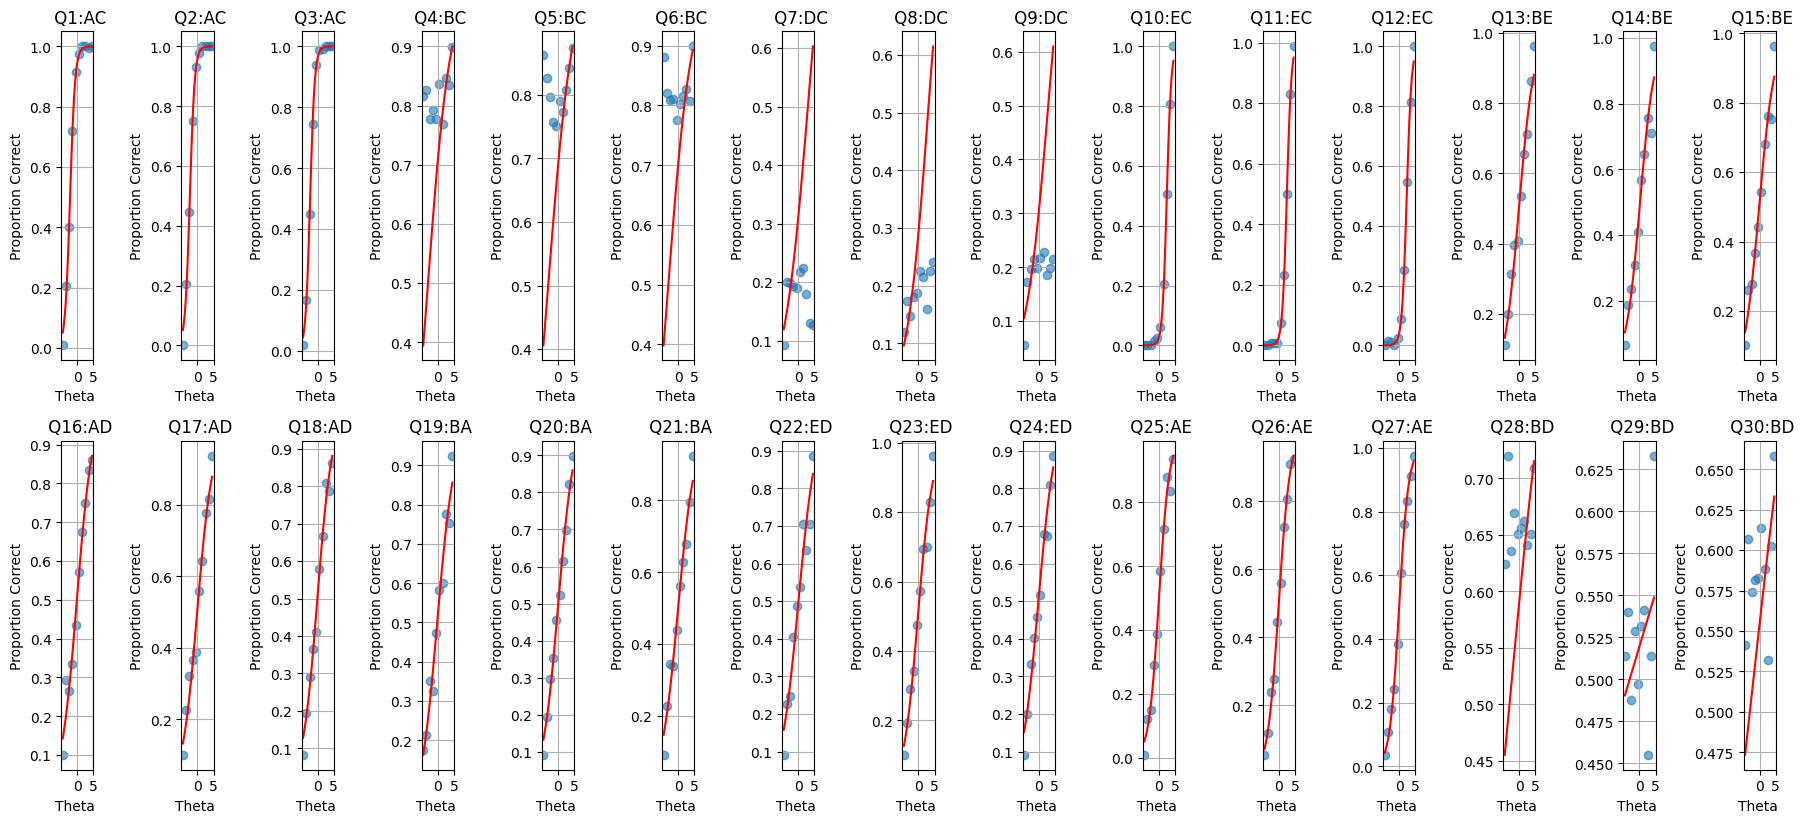


--- PC1に対する推定されたIRTパラメータ (2PL) ---
Q1:AC: a=1.2840, b=-2.2040, R²=0.9968
Q2:AC: a=1.3451, b=-2.3103, R²=0.9969
Q3:AC: a=1.4010, b=-2.2897, R²=0.9990
Q4:BC: a=0.2906, b=-3.0000, R²=-28.4003
Q5:BC: a=0.2589, b=-3.0000, R²=-26.4432
Q6:BC: a=0.2797, b=-3.0000, R²=-38.5627
Q7:DC: a=0.2676, b=3.0000, R²=-30.4904
Q8:DC: a=0.2996, b=3.0000, R²=-27.0906
Q9:DC: a=0.2857, b=3.0000, R²=-17.2560
Q10:EC: a=1.4613, b=2.5139, R²=0.9978
Q11:EC: a=1.4158, b=2.4775, R²=0.9978
Q12:EC: a=1.3494, b=2.3886, R²=0.9974
Q13:BE: a=0.4305, b=-0.0856, R²=0.9739
Q14:BE: a=0.4594, b=0.2177, R²=0.9672
Q15:BE: a=0.4172, b=-0.1088, R²=0.9713
Q16:AD: a=0.4097, b=-0.0986, R²=0.9798
Q17:AD: a=0.4265, b=-0.0667, R²=0.9777
Q18:AD: a=0.4345, b=-0.0474, R²=0.9851
Q19:BA: a=0.3783, b=-0.1514, R²=0.9682
Q20:BA: a=0.4087, b=0.1234, R²=0.9885
Q21:BA: a=0.3901, b=0.0289, R²=0.9724
Q22:ED: a=0.3669, b=0.0891, R²=0.9492
Q23:ED: a=0.4447, b=-0.1325, R²=0.9833
Q24:ED: a=0.3869, b=-0.0326, R²=0.9757
Q25:AE: a=0.6398, b=0.0930, R²=0.98

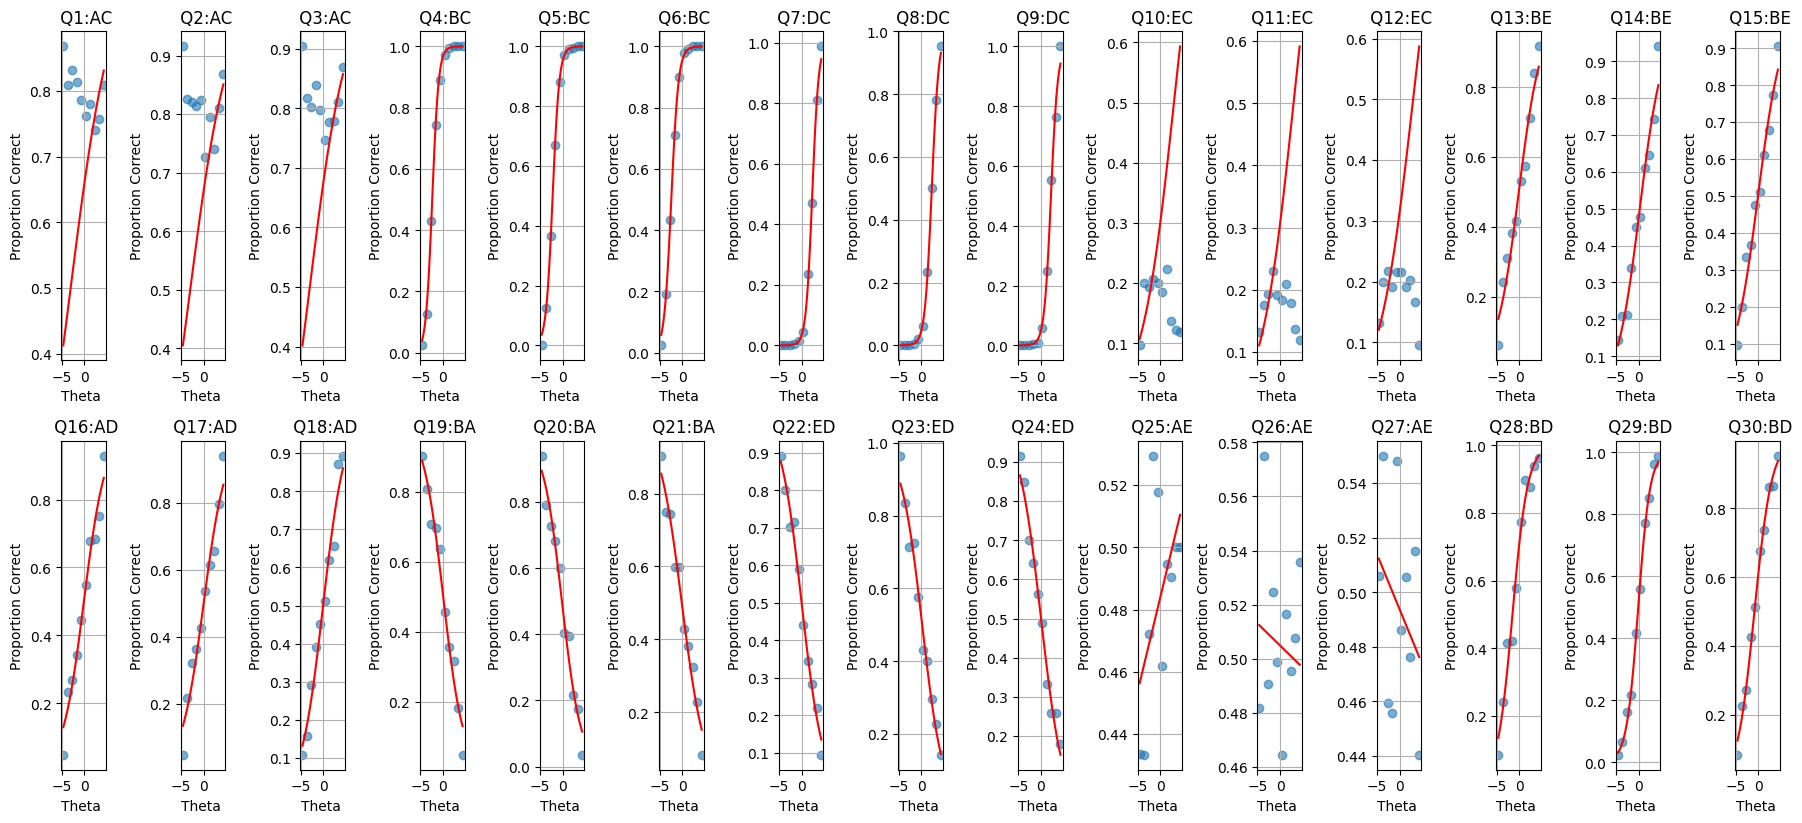


--- PC2に対する推定されたIRTパラメータ (2PL) ---
Q1:AC: a=0.2164, b=-3.0000, R²=-38.6038
Q2:AC: a=0.2368, b=-3.0000, R²=-20.3775
Q3:AC: a=0.2436, b=-3.0000, R²=-27.2807
Q4:BC: a=1.4110, b=-2.3732, R²=0.9985
Q5:BC: a=1.3497, b=-2.1823, R²=0.9989
Q6:BC: a=1.2486, b=-2.3967, R²=0.9987
Q7:DC: a=1.4260, b=2.3481, R²=0.9965
Q8:DC: a=1.2960, b=2.3370, R²=0.9993
Q9:DC: a=1.3272, b=2.2443, R²=0.9948
Q10:EC: a=0.2788, b=3.0000, R²=-28.9681
Q11:EC: a=0.2734, b=3.0000, R²=-44.2773
Q12:EC: a=0.2602, b=3.0000, R²=-32.9572
Q13:BE: a=0.4070, b=-0.0823, R²=0.9656
Q14:BE: a=0.3932, b=0.2244, R²=0.9678
Q15:BE: a=0.3780, b=-0.0749, R²=0.9752
Q16:AD: a=0.4176, b=-0.0656, R²=0.9699
Q17:AD: a=0.4044, b=-0.0248, R²=0.9615
Q18:AD: a=0.4118, b=-0.0584, R²=0.9728
Q19:BA: a=-0.4450, b=0.0677, R²=0.9753
Q20:BA: a=-0.4760, b=-0.1295, R²=0.9762
Q21:BA: a=-0.3886, b=-0.0679, R²=0.9709
Q22:ED: a=-0.4237, b=-0.0127, R²=0.9854
Q23:ED: a=-0.4278, b=0.2030, R²=0.9788
Q24:ED: a=-0.3989, b=0.0456, R²=0.9809
Q25:AE: a=0.0242, b=2.6271, R

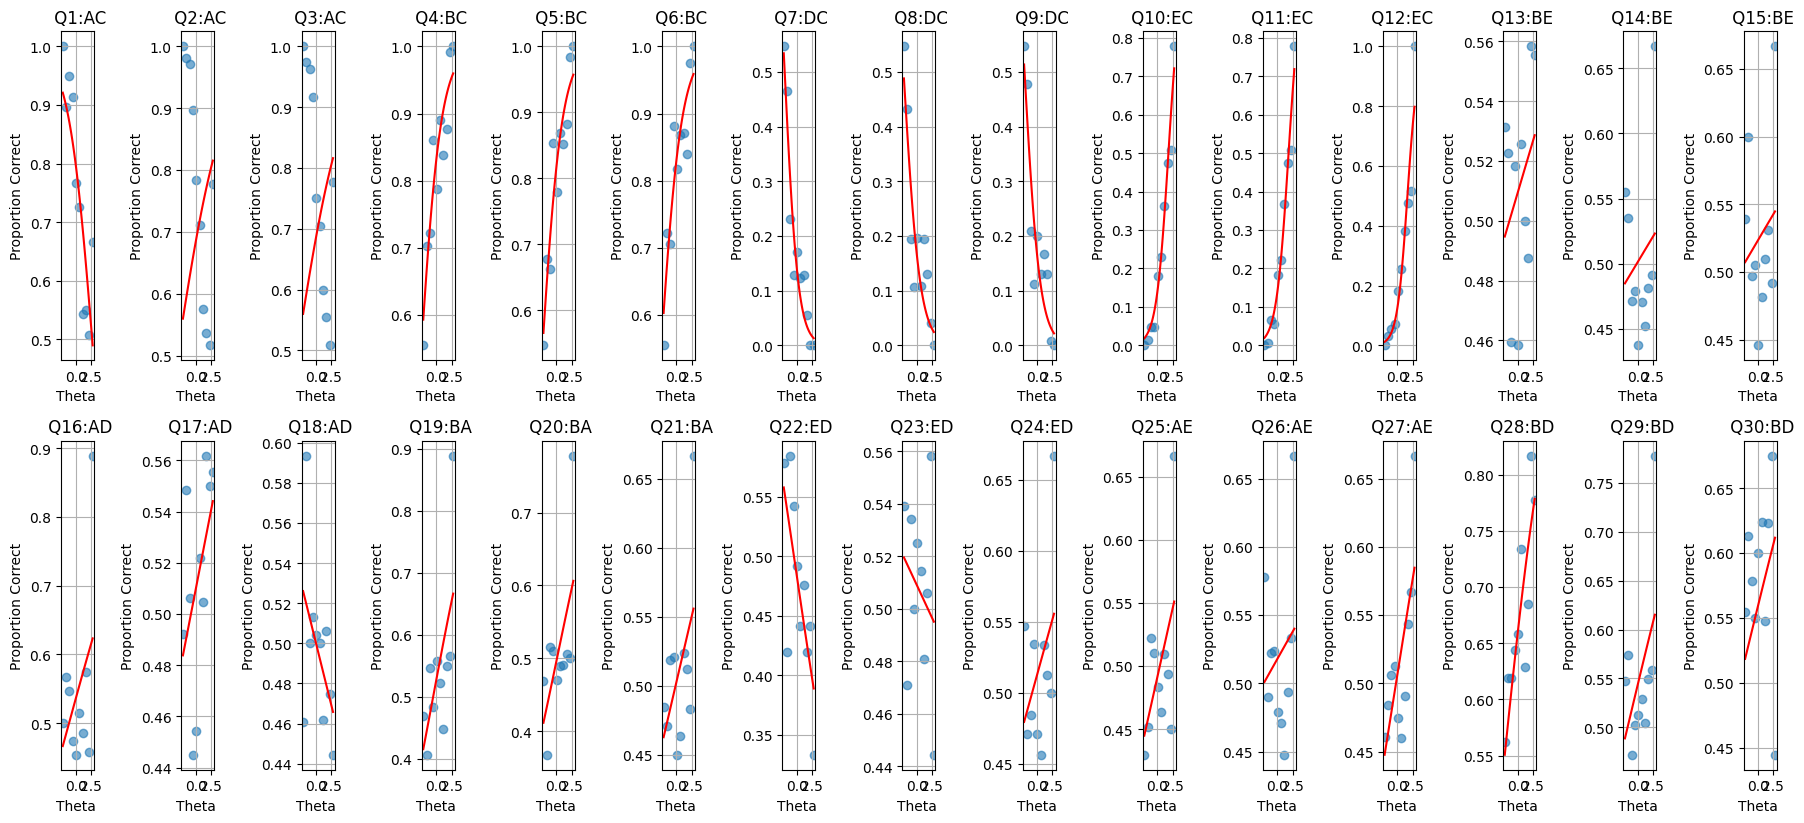


--- PC3に対する推定されたIRTパラメータ (2PL) ---
Q1:AC: a=-0.5172, b=2.6850, R²=0.7314
Q2:AC: a=0.2577, b=-3.0000, R²=-1.1994
Q3:AC: a=0.2587, b=-3.0000, R²=-1.2323
Q4:BC: a=0.5791, b=-2.7165, R²=0.8703
Q5:BC: a=0.5887, b=-2.5154, R²=0.8954
Q6:BC: a=0.5657, b=-2.8047, R²=0.8372
Q7:DC: a=-0.9236, b=-1.9176, R²=0.9267
Q8:DC: a=-0.7538, b=-2.1285, R²=0.8055
Q9:DC: a=-0.7982, b=-1.9972, R²=0.8399
Q10:EC: a=1.0200, b=1.8336, R²=0.9737
Q11:EC: a=1.0066, b=1.8309, R²=0.9728
Q12:EC: a=1.1992, b=1.6170, R²=0.9172
Q13:BE: a=0.0281, b=-1.3161, R²=0.1053
Q14:BE: a=0.0317, b=-0.1739, R²=0.0368
Q15:BE: a=0.0312, b=-3.0000, R²=0.0297
Q16:AD: a=0.1319, b=-1.0587, R²=0.1765
Q17:AD: a=0.0500, b=-0.7721, R²=0.2387
Q18:AD: a=-0.0500, b=0.0228, R²=0.2388
Q19:BA: a=0.2140, b=-0.4731, R²=0.4263
Q20:BA: a=0.1634, b=0.1199, R²=0.4095
Q21:BA: a=0.0775, b=-0.1382, R²=0.2652
Q22:ED: a=-0.1416, b=-0.4252, R²=0.5261
Q23:ED: a=-0.0203, b=1.8073, R²=0.0568
Q24:ED: a=0.0633, b=-0.7604, R²=0.1793
Q25:AE: a=0.0884, b=0.4395, R²=0.29

In [40]:
for pc_idx in range(pca_catg.n_components):
    current_theta_scores = theta_pca_catg_scores[:, pc_idx] # 現在の軸のθスコア
    pc_name = f'PC{pc_idx + 1}'
    print(f"\n--- {pc_name}に対するIRT分析 ---")
    # 各軸に対してビンを再計算
    # N=40の場合、num_binsを減らして、各ビンに十分なサンプル数があるように調整することも検討
    # 例えば、num_bins = min(num_subjects // 5, 10) など
    bins = np.linspace(current_theta_scores.min(), current_theta_scores.max(), num_bins + 1)
    theta_bin_centers = (bins[:-1] + bins[1:]) / 2
    item_response_data = [] # (theta_bin_center, item_id, proportion)
    for item_idx in range(num_questions):
        item_responses = binarized_question_data.iloc[:, item_idx]
        bin_proportions = []
        for i in range(num_bins):
            mask = (current_theta_scores >= bins[i]) & (current_theta_scores < bins[i+1])
            if i == num_bins - 1:
                mask = (current_theta_scores >= bins[i]) & (current_theta_scores <= bins[i+1])

            responses_in_bin = item_responses[mask]
            if len(responses_in_bin) > 0:
                proportion = responses_in_bin.mean()
            else:
                proportion = np.nan
            bin_proportions.append(proportion)

        item_response_data.append(bin_proportions)
    item_proportions_df = pd.DataFrame(item_response_data).T
    item_proportions_df.columns = binarized_question_data.columns
    item_proportions_df['theta_bin_center'] = theta_bin_centers
    print("--- θビンごとの正答割合（一部）---")
    print(item_proportions_df.head())



 # --- 4. curve_fitによるパラメータ推定と適合度評価 ---
    estimated_params = {}
    r_squared_values = {}
    plt.figure(figsize=(18, 12)) # 全体像を見やすくするため、図のサイズを大きくする

    for i, q_col in enumerate(binarized_question_data.columns):
     # フィッティングに使うデータポイントを準備
        valid_data = item_proportions_df[[q_col, 'theta_bin_center']].dropna()
        x_data = valid_data['theta_bin_center'].values
        y_data = valid_data[q_col].values
        if len(x_data) > 2: # フィッティングには最低3点必要 (2パラメータ推定のため)
            try:
            # 初期値の設定 (重要): a=1, b=0 は一般的な初期値
            # bounds を設定して、aは正、bは適度な範囲に制限すると安定しやすい
            # a_min=0.01 などで識別力が0にならないようにする
                popt, pcov = curve_fit(logistic_icc, x_data, y_data, p0=[1.0, 0.0],
                                   bounds=([-5.0, -3.0], [5.0, 3.0])) # aの範囲を0.01から5、bの範囲を-3から3に制限

                a_est, b_est = popt
                estimated_params[q_col] = {'a': a_est, 'b': b_est}

            # 適合度 (R-squared) の計算
                y_predicted = logistic_icc(x_data, a_est, b_est)
                ss_res = np.sum((y_data - y_predicted)**2)
                ss_tot = np.sum((y_data - y_data.mean())**2)
                r_squared = 1 - (ss_res / ss_tot)
                r_squared_values[q_col] = r_squared
                #可視化
                plt.subplot(pca_catg.n_components, num_questions // 2, i + 1) # サブプロットの配置を動的に調整
                plt.scatter(x_data, y_data, label='Observed Proportions', alpha=0.6)
                theta_range = np.linspace(x_data.min(), x_data.max(), 100)
                plt.plot(theta_range, logistic_icc(theta_range, a_est, b_est), color='red',
                        label=f'\na={a_est:.2f}, b={b_est:.2f}\nR²={r_squared:.2f}')


                plt.title(f' {q_col}:{question_item_names.get(q_col, "Unknown")}')
                plt.xlabel('Theta ')
                #plt.ylabel('Proportion Correct')
                plt.ylabel('Proportion Correct')
                #plt.legend(fontsize=7)
                plt.grid(True)

            except RuntimeError:
                print(f"Error fitting logistic function for {pc_name} - {q_col}. Skipping.")
                stimated_params[q_col] = {'a': np.nan, 'b': np.nan}
                r_squared_values[q_col] = np.nan
        else:
            print(f"Not enough data points for {q_col}. Skipping.")
            estimated_params[q_col] = {'a': np.nan, 'b': np.nan}
            r_squared_values[q_col] = np.nan

#plt.tight_layout()
#plt.show()
    plt.subplots_adjust(hspace=0.5)
    plt.tight_layout()
    plt.show() # 各PCのループの最後に表示

    # 各PCごとの結果を別途保存または表示すると、後で比較しやすいです
    print(f"\n--- {pc_name}に対する推定されたIRTパラメータ (2PL) ---")
    for q, params in estimated_params.items():
        item_name = question_item_names.get(q, "Unknown")
        print(f"{q}:{item_name}: a={params['a']:.4f}, b={params['b']:.4f}, R²={r_squared_values[q]:.4f}")

    # ここで、各質問がそのPCに対してどの程度寄与しているかを議論できます。
    # 特に、PCAの負荷量とIRTの識別力(a)を比較すると面白いです。
    # 例: print(f"PC{pc_idx + 1}に対するQ{i+1}のPCA負荷量: {pca_loadings.loc[q_col, pc_name]:.4f}")
    # これは、上記PCループの外で、全ての分析結果をまとめて行う方が良いかもしれません。

# --- 各PCに対する最終的な解釈のまとめ ---
print("\n--- 全ての軸に対する最終的な適合度と寄与の解釈 ---")
print("R-squared (決定係数) は、モデルがデータの変動をどの程度説明しているかを示します。")
print("1に近いほど適合度が高いと言えます。")
print("a（識別力）が正で大きいほど、その質問は能力をよく識別しています。")
print("b（困難度）は、その質問に50%の確率で正答する能力水準を示します。")
print("aが負の値やR-squaredが低い質問は、意図した能力を測れていない可能性があります。")
print("\n各質問のPCA負荷量と、各軸に対するIRTのa値とR^2値を比較することで、")
print("質問がどの潜在能力（軸）に強く寄与しているかを判断できます。")


# 全ての推定パラメータをまとめる（オプション）
all_estimated_params = {}
all_r_squared_values = {}
# ... 各PCループ内でestimated_paramsとr_squared_valuesを適切なキーで保存するなどして、ここに集約します。

# print("\n--- 推定されたIRTパラメータ (2PL) ---")
# for q, params in estimated_params.items():
#     print(f"{q}: a={params['a']:.4f}, b={params['b']:.4f}, R²={r_squared_values[q]:.4f}")

# # --- 適合度と寄与の解釈 ---
# print("\n--- 適合度と寄与の解釈 ---")
# print("R-squared (決定係数) は、モデルがデータの変動をどの程度説明しているかを示します。")
# print("1に近いほど適合度が高いと言えます。")
# print("a（識別力）が正で大きいほど、その質問は能力をよく識別しています。")
# print("b（困難度）は、その質問に50%の確率で正答する能力水準を示します。")
# print("aが負の値やR-squaredが低い質問は、意図した能力を測れていない可能性があります。")

IRT:item responce theory 項目応答理論

1.横軸に能力値θ、縦軸に正答率をプロットする。

2.能力値が正規分布に従うと仮定すると、そのカーブは累積正規分布＝ロジスティック関数になる。

3.問題毎にロジスティックカーブが定義でき、能力値θが十分に正しそうであれば、IRTパラメータを持つ問題を複数解かせて、その正答率を見ることで能力の推定が可能。

4.ここでは問題毎にロジスティック関数の傾きa（識別力）と能力値のどこを判別できるかを決定するb（困難度）を推定する。

5.また、この問題では能力が2つ（3つ）の前提なので、各能力に対して適応度も同時に計測する。

IRT分析前処理、各自の解答をPCA分析で拾った3成分loadingsの軸上の値（因子量）として変換する。

FAの結果を使った方が本来良いが…ここではPCAで行う。

# **言い訳的後書き**



このコードはデータサイエンスの入り口に立っている高校1年年代の高専生を対象として、AIサポートのハンズオン付き、カテゴリカルデータ解析演習用に作ったものです。データサイエンスがおもろいと思ってくれる入口になればなあ。

１．統計（数学）的に曖昧かつ怪しいことをしています。
例：非線形最小二乗フィットでなくベイジアンの最尤推定でIRTをやるのが正統なのに…


2．用語がところどころ専門家から見ると間違っている可能性があります。コードが洗練されてないとか。物理系実験屋が文部科学省（と学校）の無茶ぶりででっち上げた低学年学習用です。

　　＊＊pyirt とかpy-irtとかmirt(via R)とか使えって話はあるんですが、前二つはライブラリの整合がうまくいかないのよね。PCAとかFAとかを別にすれば行けるかなあ（めんどくさい）。R利用は選定教科書がpythonなので、ちょっとはずれるので泣く泣く（嘘）

3．もっと手前の統計量、平均、分散、不確かさ、確率密度関数、ｔ検定、カイ検定の話が先では？

文部科学省がＡＩ利用のデータサイエンス人材とか言う無茶を言わなきゃそうしても良いけど。

同時に伝統的統計授業は睡眠学習になるので、ＡＩへつながる部分＋ＡＩサポートでコーディングできる部分で説明。

　　＊＊計測の授業で実践して眠らせた実績付き。

ということで、良い子の皆は興味を持ったら深い沼（基、楽しい学問の深淵）がこの先拡がっているので、頑張れ。